In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))


                           

                                                            
                                            

BASE_DIR = Path().resolve()
PROJECT_ROOT = BASE_DIR.parent   #to go un up the the root
DATA_DIR = PROJECT_ROOT / "data"

# Root directory of dataset
root = Path(DATA_DIR)


import numpy as np
import matplotlib.pyplot as plt 
from scipy.signal import find_peaks
import pandas as pd

In [2]:


def build_df(root):

    label_map = {
        1: "correct",
        2: "fast",
        3: "low_amplitude"
    }

    dfs = []   # store all partial dataframes

    for subject_dir in root.glob("s*"):
        for exercise_dir in subject_dir.glob("e*"):
            for unit_dir in exercise_dir.glob("u*"):

                file_path = unit_dir / "test.txt"

                df = pd.read_csv(file_path, sep=";")

                df["subject"] = subject_dir.name
                df["exercise"] = exercise_dir.name
                df["unit"] = unit_dir.name

                

                label_map = {
                    0: "correct",
                    1: "fast",
                    2: "low_amplitude"
                }

                segment_length = len(df) // 30

                df["execution_type"] = None

                for i in range(30):
                    start = i * segment_length
                    end = (i + 1) * segment_length

                    label_group = i // 10
                    label = label_map[label_group]

                    df.loc[start:end, "execution_type"] = label

                dfs.append(df)   # collect dataframe

    final_df = pd.concat(dfs, ignore_index=True)

    return final_df

In [ ]:
df=build_df(root)


In [ ]:
df[(df['subject']=='s1') & (df['exercise']=='e1') ]

,time index,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,mag_x,mag_y,mag_z,subject,exercise,unit,execution_type
0,1,-9.685645,-1.645149,0.505022,-0.020696,0.009202,-0.008566,0.589728,0.453403,-0.075234,s1,e1,u1,correct
1,2,-9.648184,-1.645353,0.513125,-0.008165,-0.001407,-0.003256,0.587024,0.453644,-0.075593,s1,e1,u1,correct
2,3,-9.700570,-1.615223,0.512321,-0.004447,0.011059,-0.008589,0.589691,0.454598,-0.075525,s1,e1,u1,correct
3,4,-9.685627,-1.630183,0.497591,-0.026110,0.009183,-0.008554,0.589240,0.452864,-0.074705,s1,e1,u1,correct
4,5,-9.655697,-1.630194,0.460742,-0.008109,0.001231,-0.005950,0.589647,0.452882,-0.076429,s1,e1,u1,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29740,5945,-4.223868,-7.541800,-4.607269,-0.016858,-0.001904,-0.011902,0.003246,0.725318,0.231512,s1,e1,u5,None
29741,5946,-4.253123,-7.531929,-4.612775,-0.006980,-0.021866,-0.013705,0.005410,0.724710,0.231259,s1,e1,u5,None
29742,5947,-4.233624,-7.536894,-4.607502,-0.013551,-0.001552,0.000465,0.004094,0.725666,0.233084,s1,e1,u5,None
29743,5948,-4.228771,-7.517463,-4.622438,-0.020245,-0.013049,-0.019876,0.004089,0.724876,0.232979,s1,e1,u5,None


In [ ]:
merged_df = df.pivot(
    index=["subject", "exercise", "time index"],
    columns="unit",
    values=["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z", "mag_x", "mag_y", "mag_z"]
)

merged_df.columns = [f"{sensor}_{unit}" for sensor, unit in merged_df.columns]
merged_df = merged_df.reset_index()




In [ ]:
subject2ex1=merged_df[(merged_df['subject']=='s2') & (merged_df['exercise']=='e1') ]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#### accelerometer magnitude of exercise 2 for subject 2 of one sensor unit

exercise 2 is moving the leg, the most used sensor shuold be only s2

In [ ]:
def analyze_subject_exercises(subject, merged_df):
    subject_df = merged_df[merged_df['subject'] == subject]
    exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

    all_subject_ex = {}

    for exercise in exercises:
        subject_ex = subject_df[subject_df['exercise'] == exercise].copy()

        if subject_ex.empty:
            print(f"No data for {exercise}")
            continue

        unit_activity = {}

        # Compute magnitudes for all units
        for u in range(1, 6):
            subject_ex[f"acc_mag_u{u}"] = np.sqrt(
                subject_ex[f"acc_x_u{u}"]**2 +
                subject_ex[f"acc_y_u{u}"]**2 +
                subject_ex[f"acc_z_u{u}"]**2
            )

            subject_ex[f"gyr_mag_u{u}"] = np.sqrt(
                subject_ex[f"gyr_x_u{u}"]**2 +
                subject_ex[f"gyr_y_u{u}"]**2 +
                subject_ex[f"gyr_z_u{u}"]**2
            )

            subject_ex[f"mag_mag_u{u}"] = np.sqrt(
                subject_ex[f"mag_x_u{u}"]**2 +
                subject_ex[f"mag_y_u{u}"]**2 +
                subject_ex[f"mag_z_u{u}"]**2
            )

            total_std = (
                subject_ex[f"acc_mag_u{u}"].std() +
                subject_ex[f"gyr_mag_u{u}"].std() +
                subject_ex[f"mag_mag_u{u}"].std()
            )
            unit_activity[f"u{u}"] = total_std

        # Determine most active unit AFTER all units are processed
        most_active_unit = max(unit_activity, key=unit_activity.get)

        print(f"\n{exercise} — most active unit: {most_active_unit}")
        print({k: round(v, 4) for k, v in unit_activity.items()})

        # Add the column to the dataframe
        subject_ex["most_active_unit"] = most_active_unit

        # Save dataframe
        all_subject_ex[exercise] = subject_ex

        threshold = 0.1

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"Subject {subject} - {exercise}")

        sensor_info = [
            ("acc", "Acceleration magnitude", axes[0]),
            ("gyr", "Gyroscope magnitude", axes[1]),
            ("mag", "Magnetometer magnitude", axes[2]),
        ]

        anything_plotted = False

        for sensor_prefix, title, ax in sensor_info:
            plotted_here = False

            for u in range(1, 6):
                std = subject_ex[f"{sensor_prefix}_mag_u{u}"].std()

                if std > threshold:
                    ax.plot(
                        subject_ex["time index"],
                        subject_ex[f"{sensor_prefix}_mag_u{u}"],
                        label=f"u{u} (std={std:.2f})"
                    )
                    plotted_here = True
                    anything_plotted = True

            ax.set_title(title)
            ax.set_xlabel("time index")
            ax.grid(True)

            if sensor_prefix == "acc":
                ax.set_ylabel("magnitude")

            if plotted_here:
                ax.legend()
            else:
                ax.text(
                    0.5, 0.5, "No signal above threshold",
                    transform=ax.transAxes,
                    ha="center", va="center"
                )

        if anything_plotted:
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        else:
            plt.close()
            print(f"No sensor exceeded threshold for {exercise}")

    return all_subject_ex


e1 — most active unit: u2
{'u1': np.float64(0.0676), 'u2': np.float64(2.4046), 'u3': np.float64(0.428), 'u4': np.float64(0.1271), 'u5': np.float64(0.1078)}


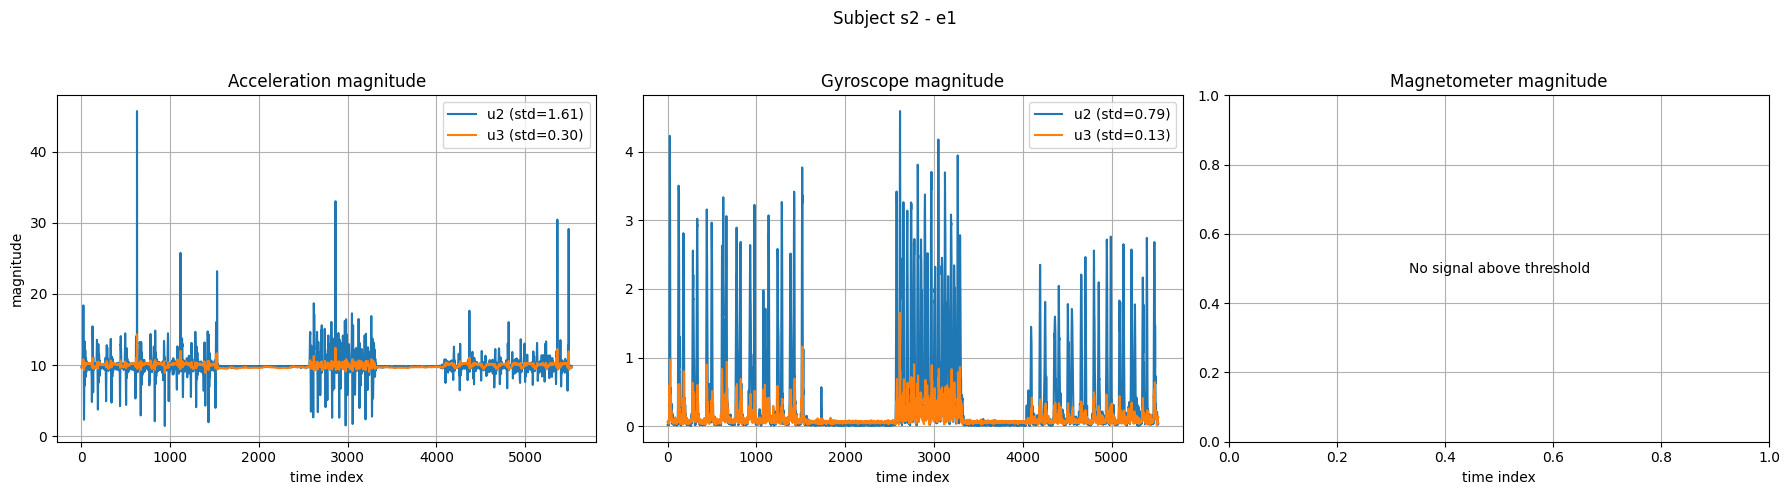


e2 — most active unit: u4
{'u1': np.float64(0.1482), 'u2': np.float64(0.1178), 'u3': np.float64(0.2077), 'u4': np.float64(0.8771), 'u5': np.float64(0.2559)}


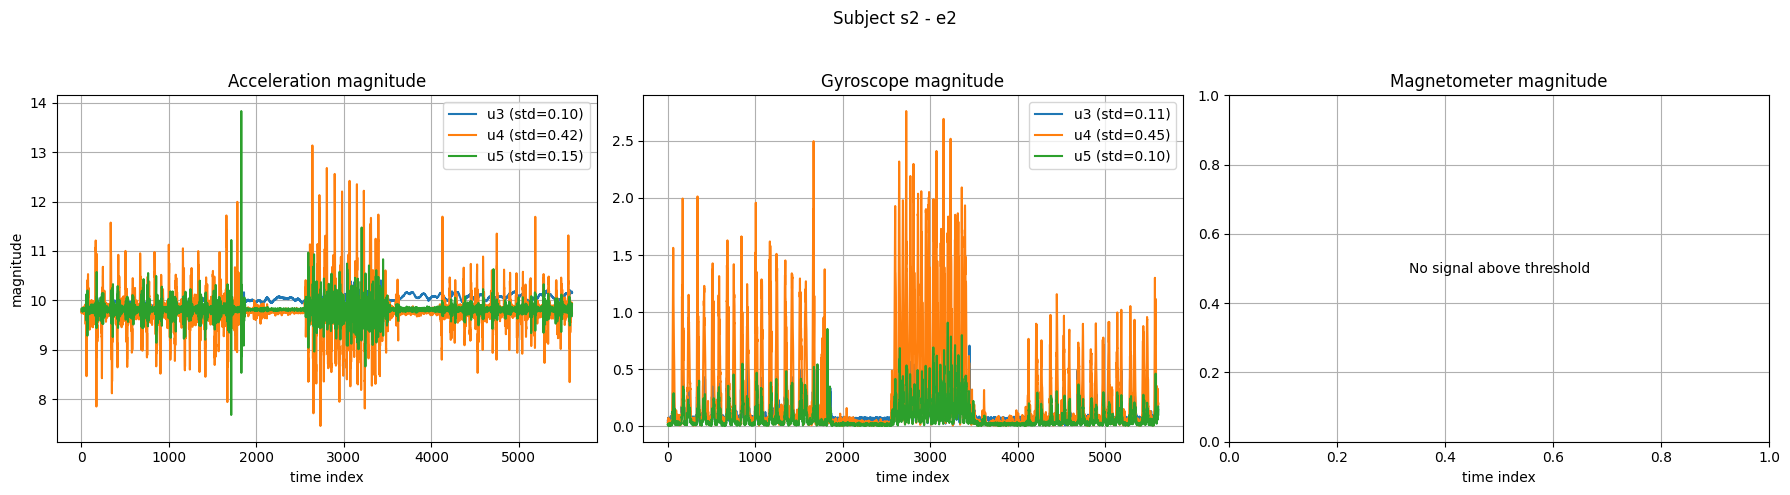


e3 — most active unit: u2
{'u1': np.float64(0.2524), 'u2': np.float64(3.5186), 'u3': np.float64(0.9461), 'u4': np.float64(0.2107), 'u5': np.float64(0.3007)}


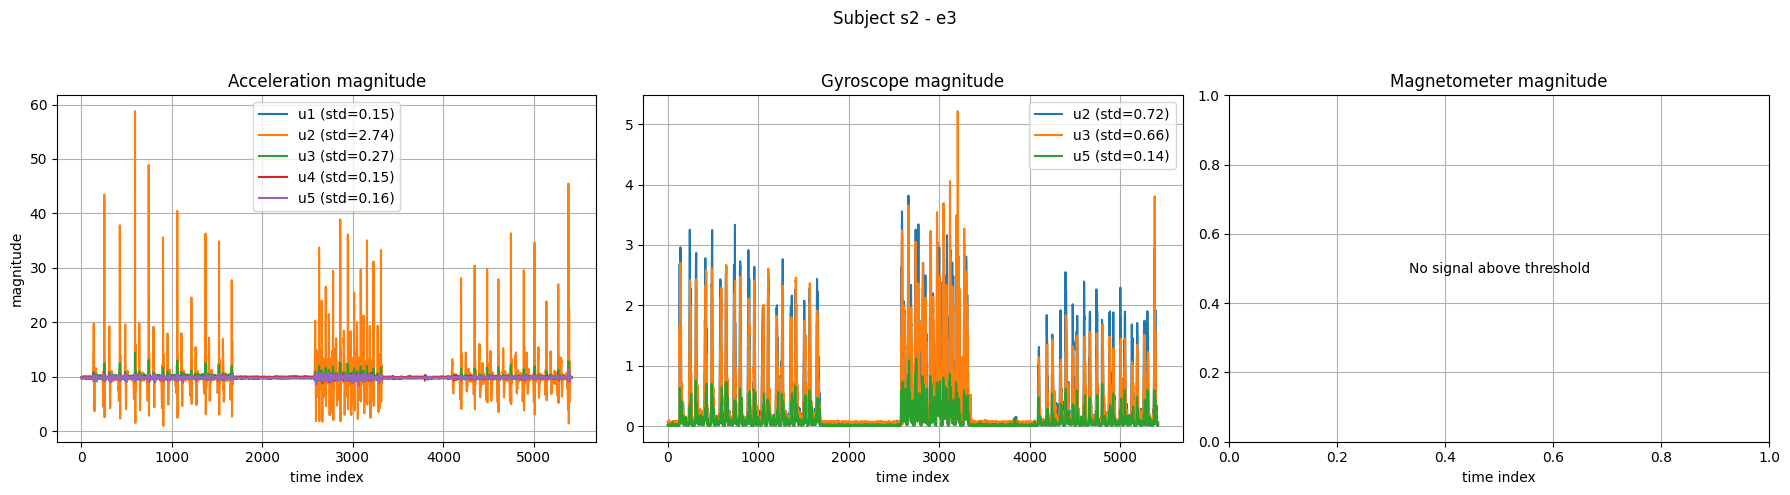


e4 — most active unit: u2
{'u1': np.float64(0.9442), 'u2': np.float64(2.6134), 'u3': np.float64(1.3653), 'u4': np.float64(0.2696), 'u5': np.float64(0.2717)}


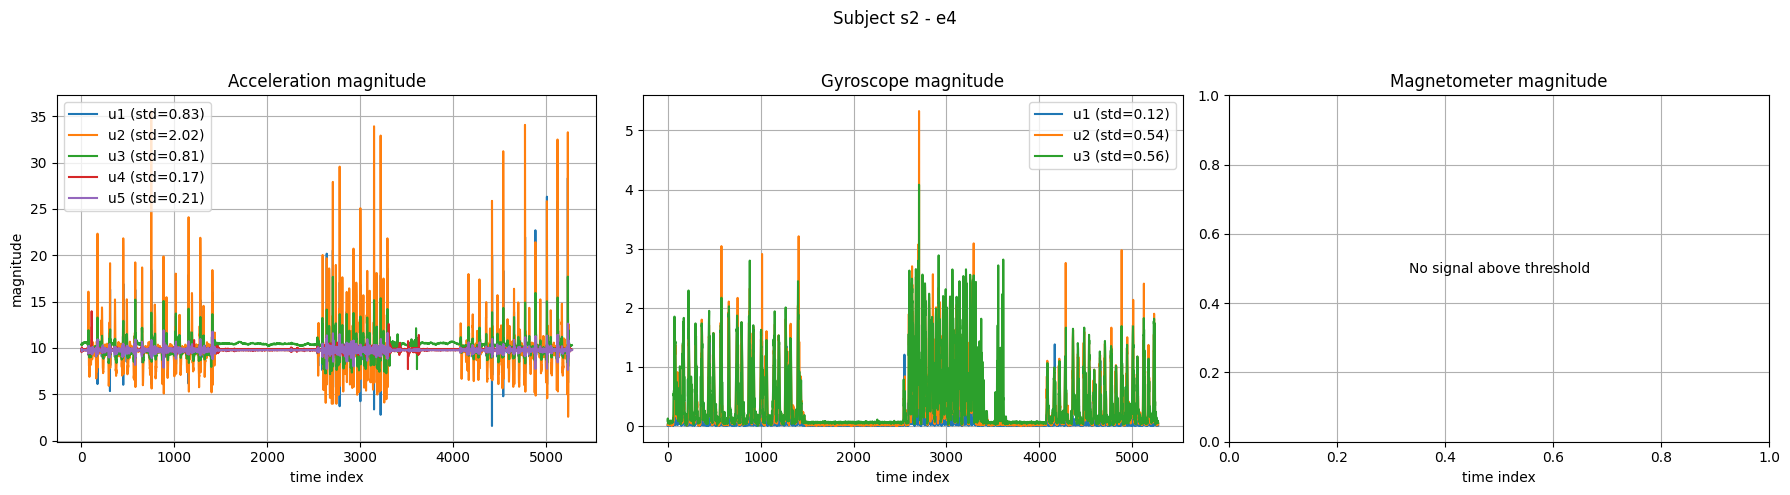


e5 — most active unit: u2
{'u1': np.float64(0.5495), 'u2': np.float64(3.4029), 'u3': np.float64(0.9198), 'u4': np.float64(0.1959), 'u5': np.float64(0.5086)}


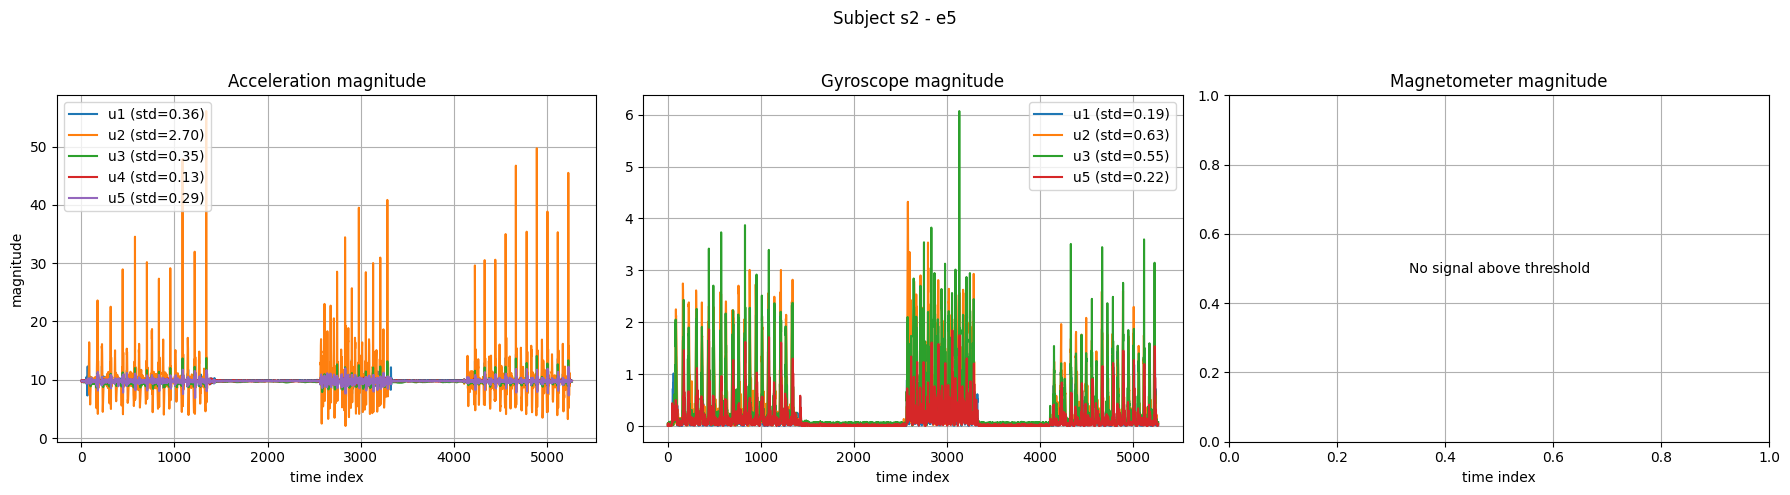


e6 — most active unit: u2
{'u1': np.float64(0.0986), 'u2': np.float64(3.5378), 'u3': np.float64(1.3337), 'u4': np.float64(0.2387), 'u5': np.float64(0.103)}


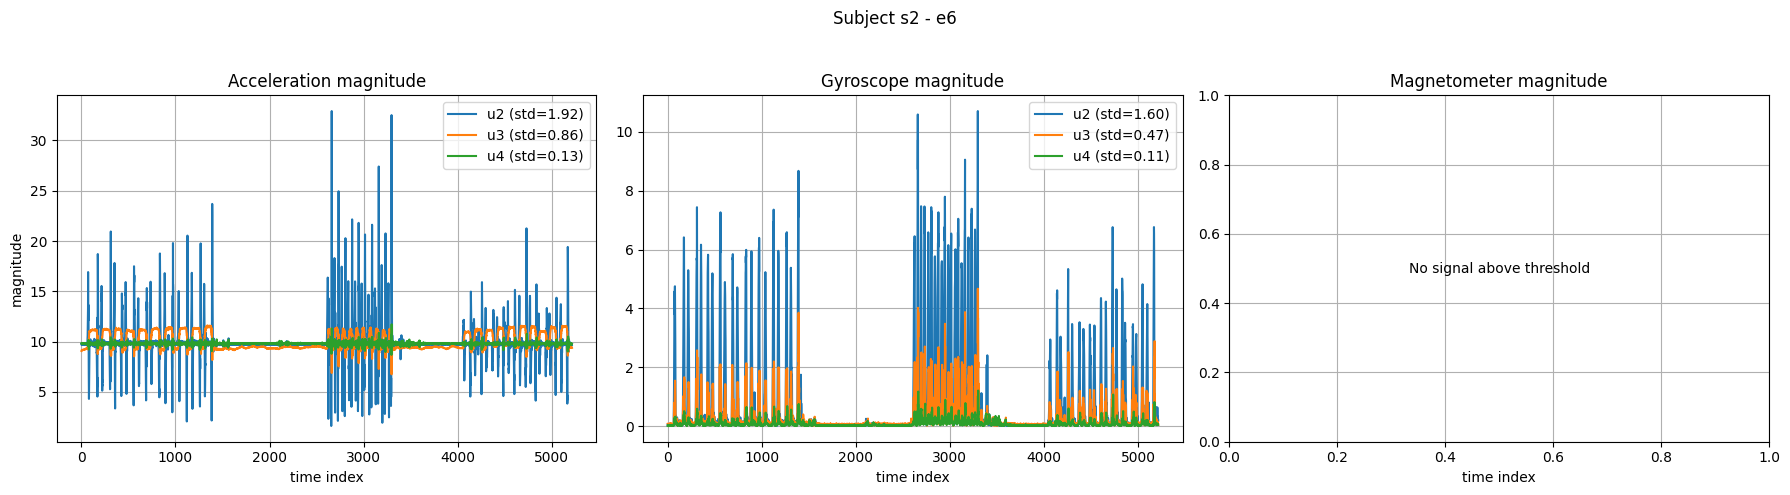


e7 — most active unit: u3
{'u1': np.float64(0.4422), 'u2': np.float64(3.4324), 'u3': np.float64(3.7217), 'u4': np.float64(1.0661), 'u5': np.float64(0.201)}


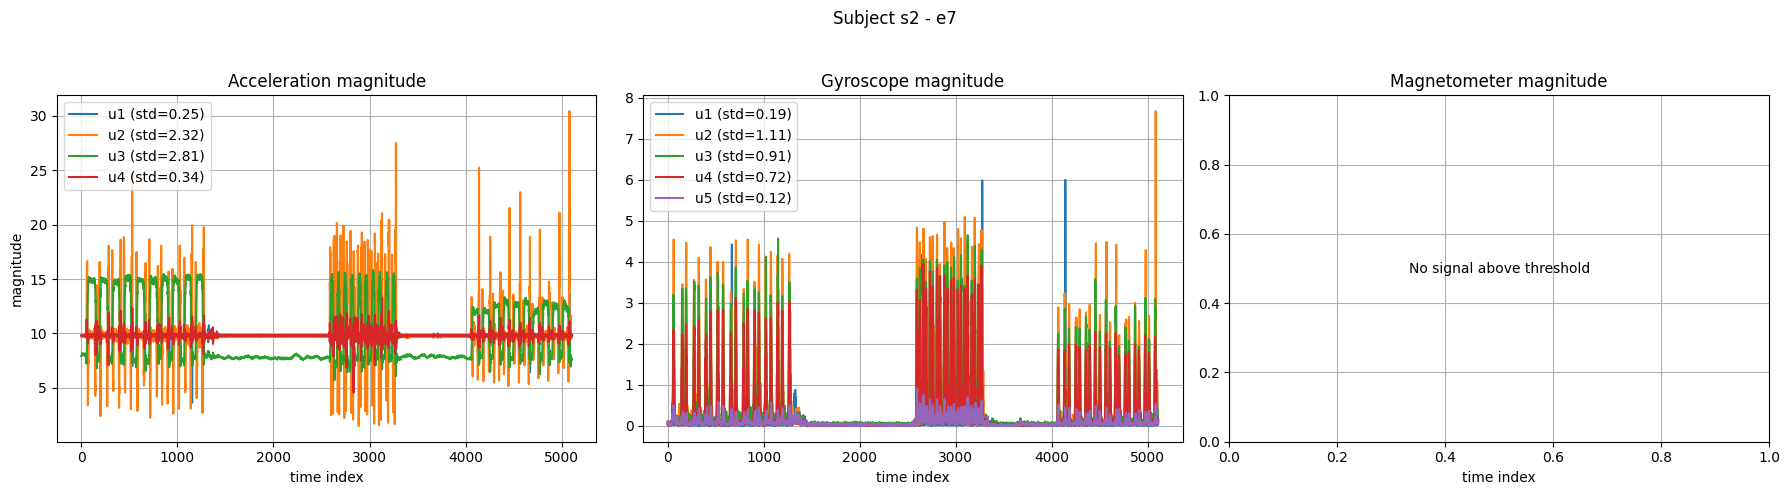


e8 — most active unit: u2
{'u1': np.float64(0.1054), 'u2': np.float64(3.0347), 'u3': np.float64(1.8712), 'u4': np.float64(0.5884), 'u5': np.float64(0.1044)}


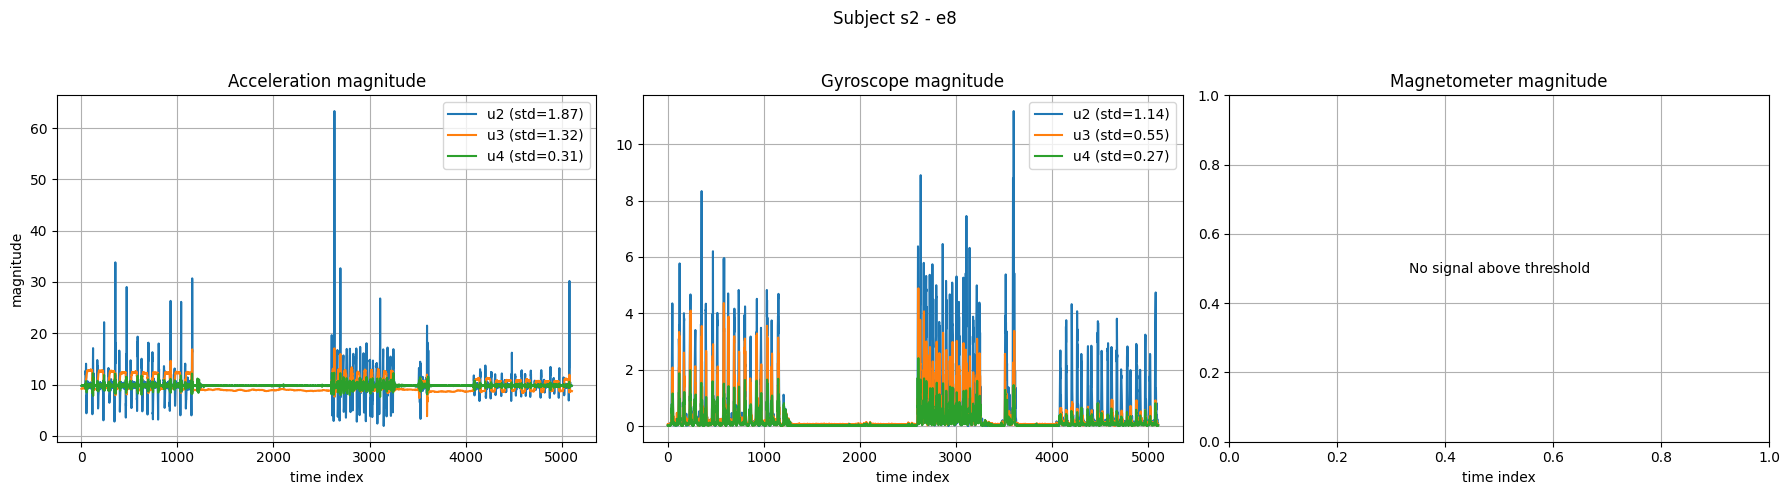

In [ ]:
subject_ex=analyze_subject_exercises('s2', merged_df)

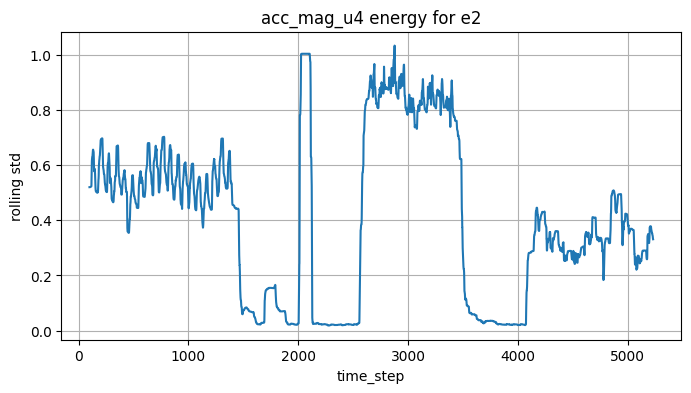

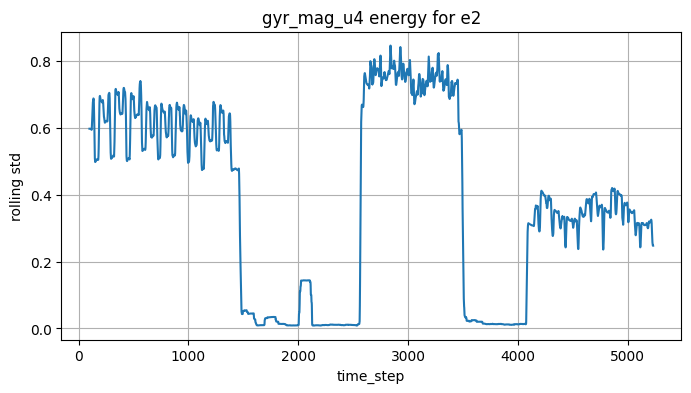

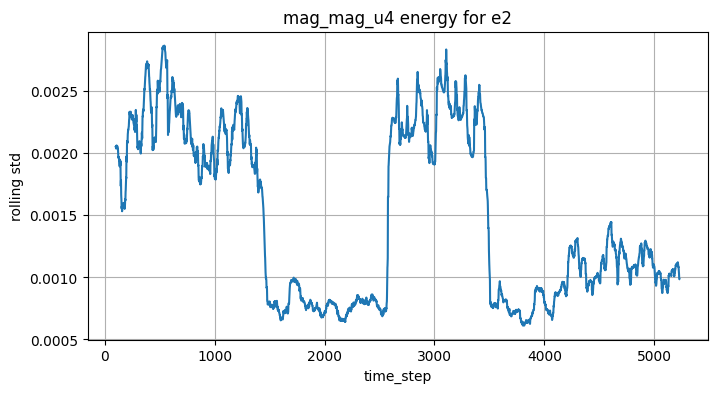

In [ ]:
exercises = ['e1','e2','e3','e4','e5','e6','e7','e8']

for ex in exercises:

    sub = subject_ex[ex]

    unit = sub['most_active_unit'].iloc[0]
    columns = [f"acc_mag_{unit}", f"gyr_mag_{unit}", f"mag_mag_{unit}"]

    # rolling std for each signal
    energies = pd.DataFrame({
        col: sub[col].rolling(100, center=True).std()
        for col in columns
    })

    # combined activity score
    activity_score = energies.mean(axis=1)

    

fig, axes = plt.subplots(len(exercises), 1, figsize=(10,18), sharex=False)

for i, ex in enumerate(exercises):

        sub = subject_ex[ex]

        unit = sub['most_active_unit'].iloc[0]
        columns = [f"acc_mag_{unit}", f"gyr_mag_{unit}", f"mag_mag_{unit}"]

        energies = pd.DataFrame({
            col: sub[col].rolling(100, center=True).std()
            for col in columns
        })

        activity_score = energies.mean(axis=1)

        axes[i].plot(activity_score)

        axes[i].set_title(ex)
        axes[i].grid(True)

plt.tight_layout()
plt.show()   

In [103]:
subject_ex['e2']

,subject,exercise,time index,acc_x_u1,acc_x_u2,acc_x_u3,acc_x_u4,acc_x_u5,acc_y_u1,acc_y_u2,...,acc_mag_u3,gyr_mag_u3,mag_mag_u3,acc_mag_u4,gyr_mag_u4,mag_mag_u4,acc_mag_u5,gyr_mag_u5,mag_mag_u5,most_active_unit
184254,s5,e2,1,-9.533362,-9.504189,-1.809200,9.119701,-4.366940,-1.547559,2.186700,...,9.871554,0.013627,0.785940,9.808414,0.028681,0.801116,9.843388,0.011903,0.798619,u4
184255,s5,e2,2,-9.525859,-9.527006,-1.793918,9.090458,-4.330389,-1.540124,2.105234,...,9.811762,0.010557,0.785875,9.792889,0.038056,0.799499,9.840754,0.007922,0.797965,u4
184256,s5,e2,3,-9.548320,-9.504155,-1.794105,9.078135,-4.349902,-1.532547,2.194109,...,9.842827,0.012624,0.784845,9.772372,0.026707,0.801825,9.835383,0.007435,0.796532,u4
184257,s5,e2,4,-9.555804,-9.496805,-1.779079,9.075587,-4.345000,-1.532538,2.179172,...,9.824418,0.023200,0.784418,9.763152,0.022277,0.799556,9.835775,0.008336,0.797669,u4
184258,s5,e2,5,-9.593254,-9.504155,-1.794144,9.071011,-4.344994,-1.532386,2.194109,...,9.849764,0.027982,0.784188,9.765696,0.016097,0.800251,9.850630,0.015892,0.797542,u4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189479,s5,e2,5226,-9.192701,-9.367926,-1.536827,8.956985,0.215345,-2.655642,2.328614,...,9.797812,0.021634,0.785127,9.773246,0.015284,0.799336,9.832376,0.013397,0.796580,u4
189480,s5,e2,5227,-9.177775,-9.382869,-1.499447,8.962049,0.227501,-2.685570,2.328675,...,9.788762,0.030410,0.785149,9.778624,0.018484,0.799399,9.821504,0.013216,0.796893,u4
189481,s5,e2,5228,-9.192701,-9.382661,-1.499477,8.937196,0.205533,-2.655642,2.358429,...,9.796335,0.023827,0.785239,9.766108,0.018212,0.799606,9.811177,0.007556,0.796956,u4
189482,s5,e2,5229,-9.177763,-9.405239,-1.514725,8.983777,0.220177,-2.678099,2.314125,...,9.852117,0.016347,0.784711,9.798102,0.025638,0.798887,9.825507,0.014607,0.797139,u4


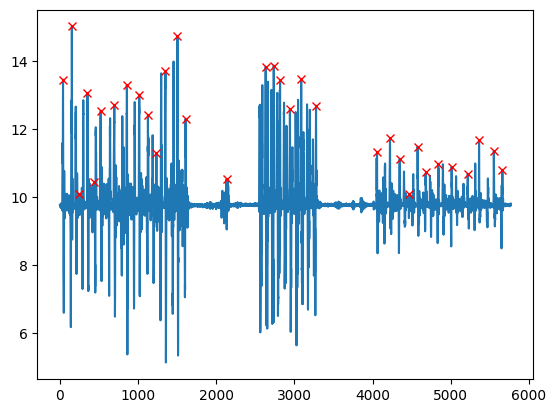

In [56]:
signal = subject_ex["acc_mag_u2"].to_numpy()
peaks, _ = find_peaks(signal, distance=80, prominence=0.6)

plt.plot(signal)
plt.plot(peaks, signal[peaks], "xr")
plt.show()



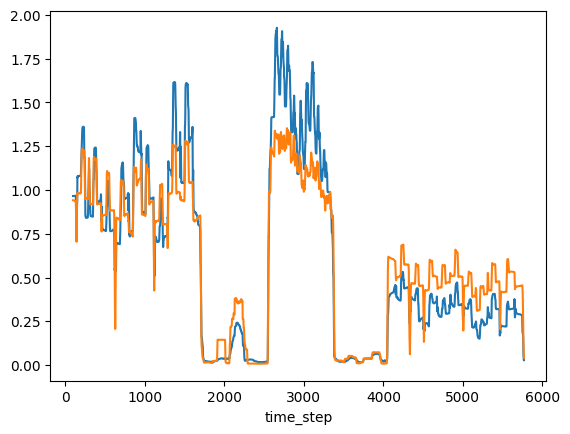

In [79]:
subject_ex['e1'].columns

Index(['subject', 'exercise', 'time index', 'acc_x_u1', 'acc_x_u2', 'acc_x_u3',
       'acc_x_u4', 'acc_x_u5', 'acc_y_u1', 'acc_y_u2', 'acc_y_u3', 'acc_y_u4',
       'acc_y_u5', 'acc_z_u1', 'acc_z_u2', 'acc_z_u3', 'acc_z_u4', 'acc_z_u5',
       'gyr_x_u1', 'gyr_x_u2', 'gyr_x_u3', 'gyr_x_u4', 'gyr_x_u5', 'gyr_y_u1',
       'gyr_y_u2', 'gyr_y_u3', 'gyr_y_u4', 'gyr_y_u5', 'gyr_z_u1', 'gyr_z_u2',
       'gyr_z_u3', 'gyr_z_u4', 'gyr_z_u5', 'mag_x_u1', 'mag_x_u2', 'mag_x_u3',
       'mag_x_u4', 'mag_x_u5', 'mag_y_u1', 'mag_y_u2', 'mag_y_u3', 'mag_y_u4',
       'mag_y_u5', 'mag_z_u1', 'mag_z_u2', 'mag_z_u3', 'mag_z_u4', 'mag_z_u5',
       'acc_mag_u1', 'gyr_mag_u1', 'mag_mag_u1', 'acc_mag_u2', 'gyr_mag_u2',
       'mag_mag_u2', 'acc_mag_u3', 'gyr_mag_u3', 'mag_mag_u3', 'acc_mag_u4',
       'gyr_mag_u4', 'mag_mag_u4', 'acc_mag_u5', 'gyr_mag_u5', 'mag_mag_u5',
       'most_active_unit'],
      dtype='str')

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def remove_short_true_segments(mask, min_len):
    mask = mask.copy()
    groups = (mask != mask.shift()).cumsum()

    for _, group in mask.groupby(groups):
        if bool(group.iloc[0]) and len(group) < min_len:
            mask.loc[group.index] = False

    return mask


def fill_short_false_gaps(mask, max_gap_len):
    mask = mask.copy()
    groups = (mask != mask.shift()).cumsum()

    segments = []
    for _, group in mask.groupby(groups):
        segments.append({
            "value": bool(group.iloc[0]),
            "start": group.index[0],
            "end": group.index[-1],
            "length": len(group)
        })

    for i in range(1, len(segments) - 1):
        prev_seg = segments[i - 1]
        curr_seg = segments[i]
        next_seg = segments[i + 1]

        if (
            prev_seg["value"] is True and
            curr_seg["value"] is False and
            next_seg["value"] is True and
            curr_seg["length"] <= max_gap_len
        ):
            mask.loc[curr_seg["start"]:curr_seg["end"]] = True

    return mask


def extract_idle_periods(mask):
    groups = (mask != mask.shift()).cumsum()
    idle_groups = mask[mask].groupby(groups[mask])
    return [(group.index[0], group.index[-1]) for _, group in idle_groups]


def find_idle_periods_adaptive(
    df,
    window_size=100,
    smooth_window=50,
    q_low=0.10,
    q_high=0.60,
    alpha=0.20,
    min_idle_len=100,
    max_gap_len=200,
    plot=True
):
    """
    Detect 2 idle periods using the most active unit, with combined energy from
    acc + gyr + mag, and an adaptive threshold.

    threshold = q_low_value + alpha * (q_high_value - q_low_value)
    """

    unit = df["most_active_unit"].iloc[0]

    acc_col = f"acc_mag_{unit}"
    gyr_col = f"gyr_mag_{unit}"
    mag_col = f"mag_mag_{unit}"

    required_cols = [acc_col, gyr_col, mag_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # Rolling local energy per modality
    acc_energy = pd.Series(df[acc_col].to_numpy()).rolling(window_size, center=True).std()
    gyr_energy = pd.Series(df[gyr_col].to_numpy()).rolling(window_size, center=True).std()
    mag_energy = pd.Series(df[mag_col].to_numpy()).rolling(window_size, center=True).std()

    # Combined energy
    energy = acc_energy + gyr_energy + mag_energy
    energy = energy.bfill().ffill()

    # Smooth
    energy_smooth = energy.rolling(smooth_window, center=True).median().bfill().ffill()

    # Adaptive threshold
    low_val = energy_smooth.quantile(q_low)
    high_val = energy_smooth.quantile(q_high)
    threshold = low_val + alpha * (high_val - low_val)

    # Raw idle mask
    idle_mask = energy_smooth < threshold

    # Clean mask
    idle_mask = remove_short_true_segments(idle_mask, min_len=min_idle_len)
    idle_mask = fill_short_false_gaps(idle_mask, max_gap_len=max_gap_len)
    idle_mask = remove_short_true_segments(idle_mask, min_len=min_idle_len)

    # Extract intervals
    idle_periods = extract_idle_periods(idle_mask)

    # Keep 2 longest
    idle_periods = sorted(idle_periods, key=lambda x: x[1] - x[0], reverse=True)[:2]
    idle_periods = sorted(idle_periods, key=lambda x: x[0])

    result = {
        "most_active_unit": unit,
        "threshold": threshold,
        "low_val": low_val,
        "high_val": high_val,
        "energy_smooth": energy_smooth,
        "idle_mask": idle_mask,
        "idle_periods": idle_periods,
        "columns_used": {
            "acc": acc_col,
            "gyr": gyr_col,
            "mag": mag_col
        }
    }

    if plot:
        plt.figure(figsize=(12, 4))
        plt.plot(energy_smooth, label="combined smoothed energy")
        plt.axhline(threshold, linestyle="--", label=f"threshold={threshold:.3f}")

        for start, end in idle_periods:
            plt.axvspan(start, end, alpha=0.2)

        plt.xlabel("time_step")
        plt.ylabel("energy")
        plt.title(f"Combined energy from {acc_col}, {gyr_col}, {mag_col}")
        plt.grid(True)
        plt.legend()
        plt.show()

        plt.figure(figsize=(12, 4))
        plt.plot(idle_mask.astype(int))
        plt.xlabel("time_step")
        plt.ylabel("idle")
        plt.title(f"Idle mask using most active unit {unit}")
        plt.grid(True)
        plt.show()

    return result

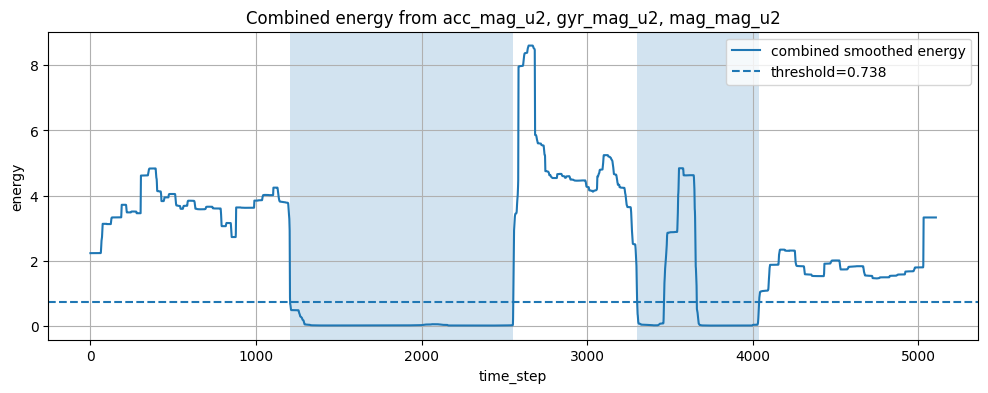

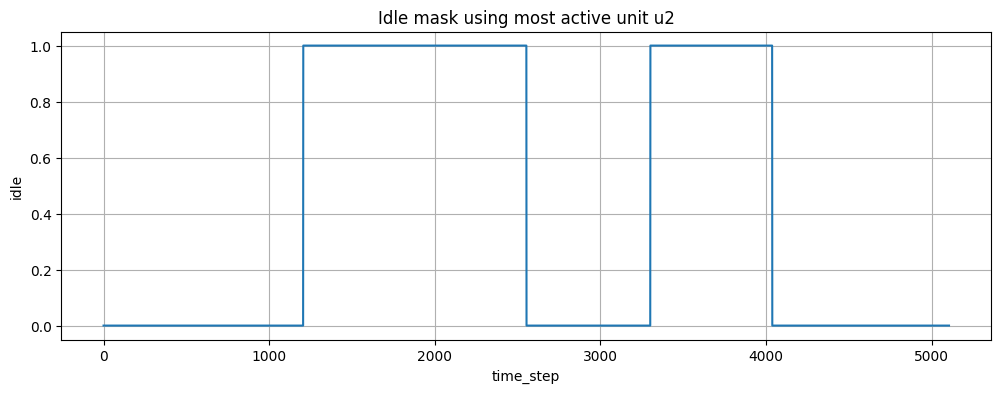

Most active unit: u2
Threshold: 0.7383
Low baseline: 0.0211
High reference: 3.607
Idle periods found: [(np.int64(1206), np.int64(2553)), (np.int64(3302), np.int64(4037))]


In [163]:
sub1 = subject_ex["e8"]

result = find_idle_periods_adaptive(
    sub1,
    window_size=100,
    smooth_window=50,
    q_low=0.10,
    q_high=0.70,
    alpha=0.20,
    min_idle_len=100,
    max_gap_len=200,
    plot=True
)

print("Most active unit:", result["most_active_unit"])
print("Threshold:", round(result["threshold"], 4))
print("Low baseline:", round(result["low_val"], 4))
print("High reference:", round(result["high_val"], 4))
print("Idle periods found:", result["idle_periods"])

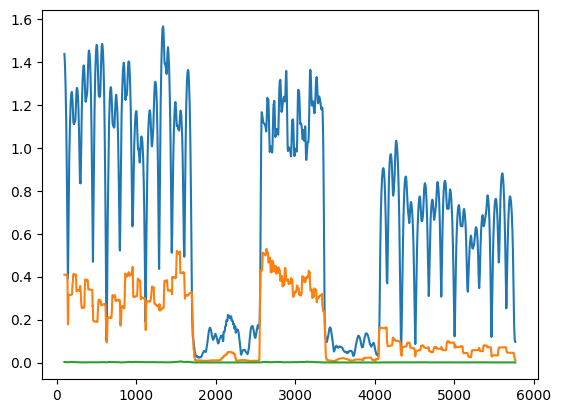

In [22]:
columns=["acc_mag_u3", 'gyr_mag_u3', 'mag_mag_u3']

for column in columns:
    signal = subject_ex[column].to_numpy()
    energy = pd.Series(signal).rolling(100).std()

    plt.plot(energy)

    

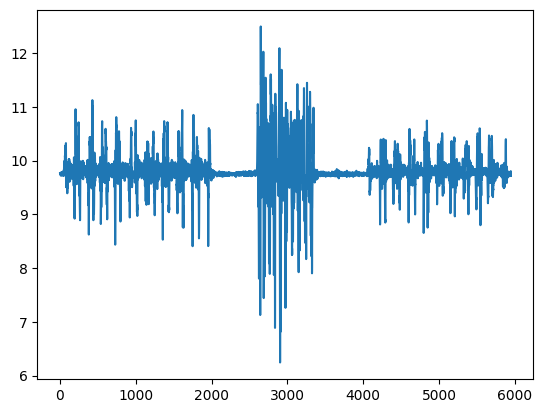

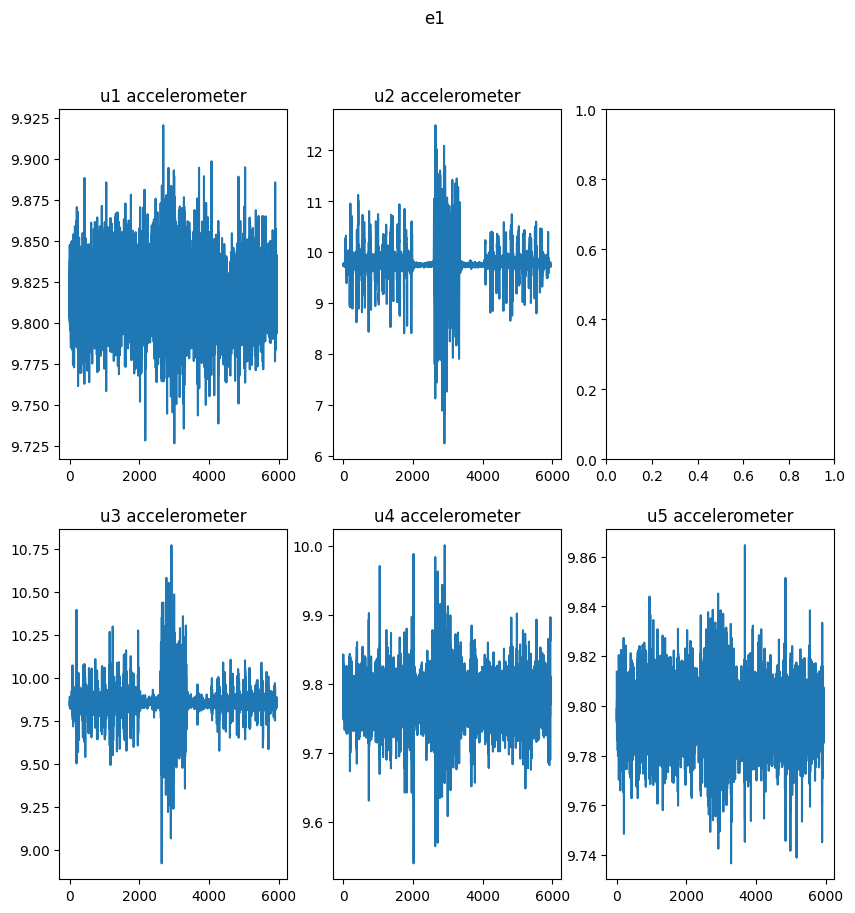

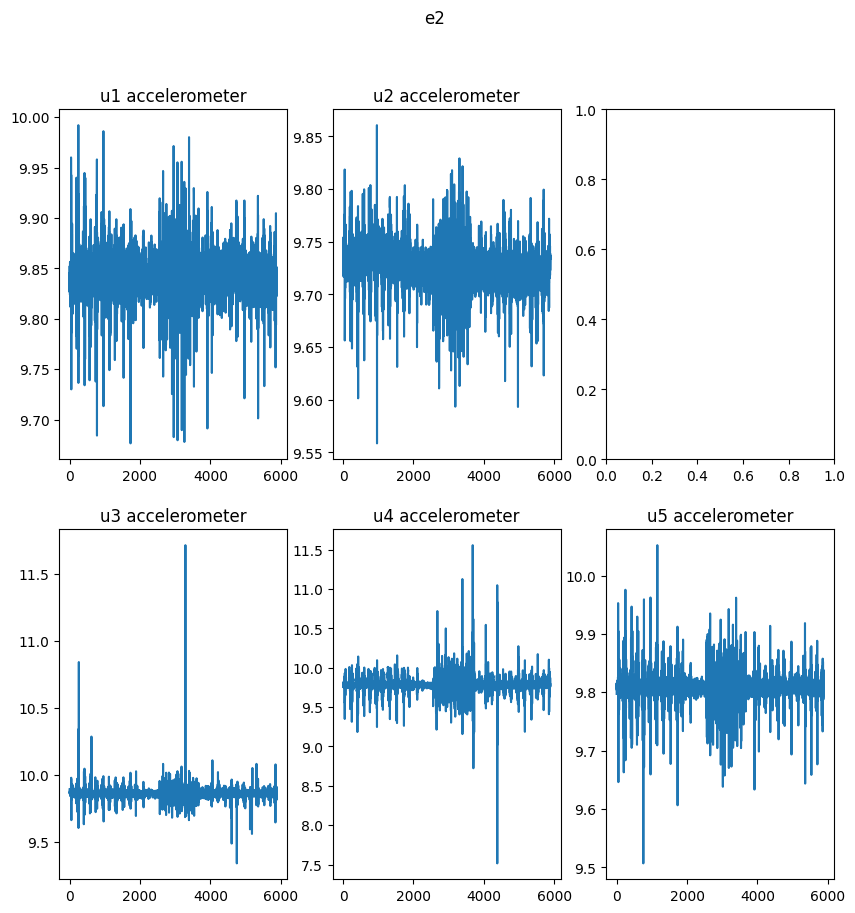

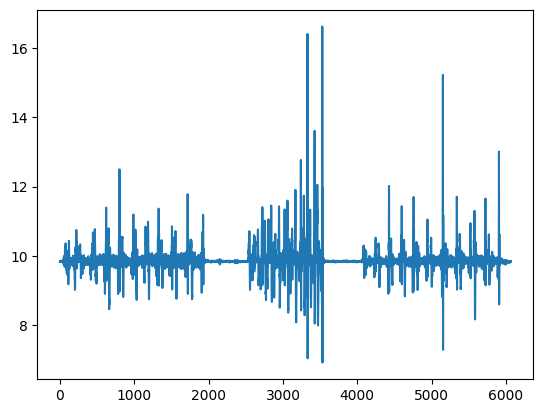

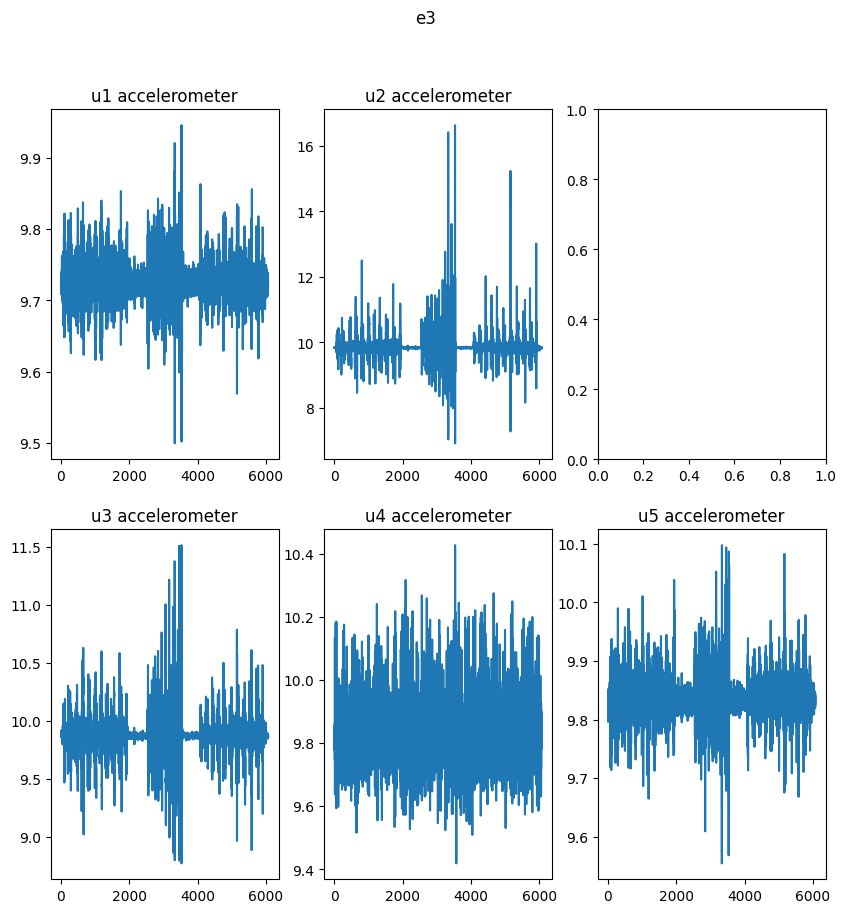

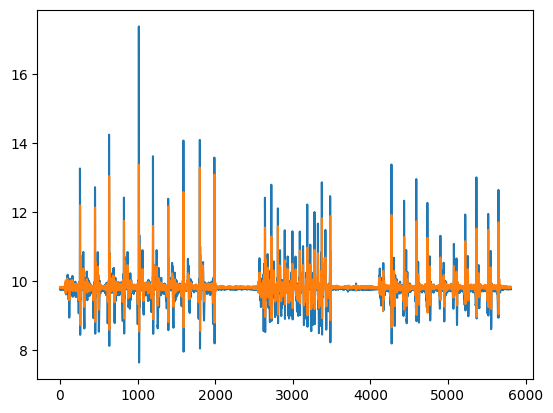

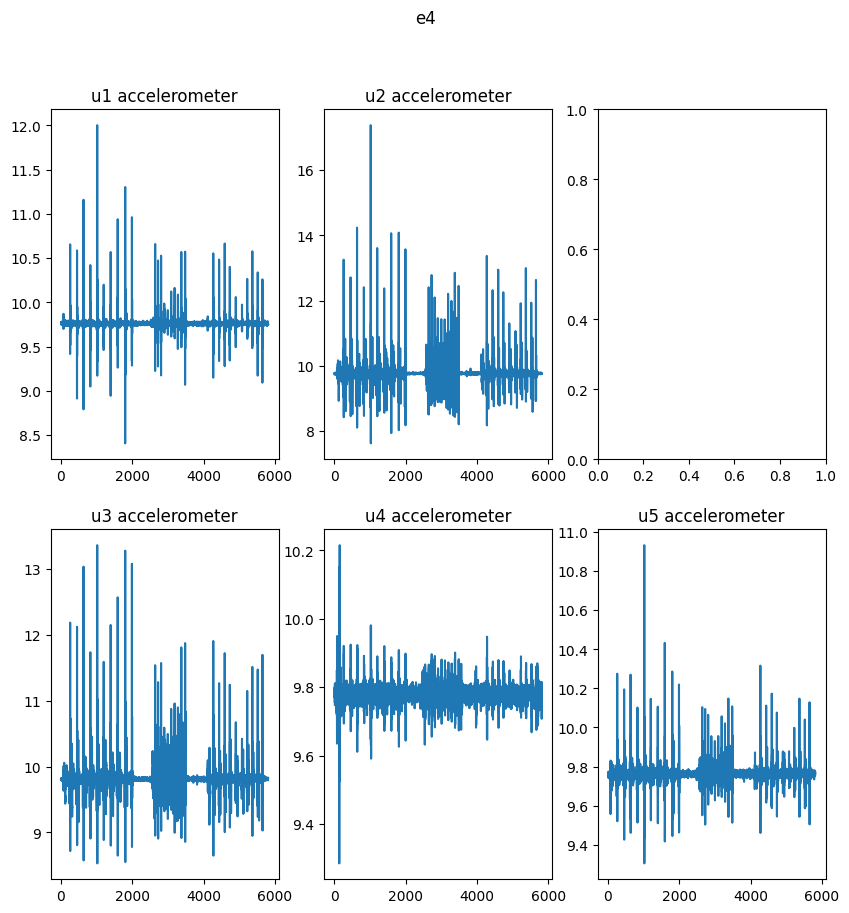

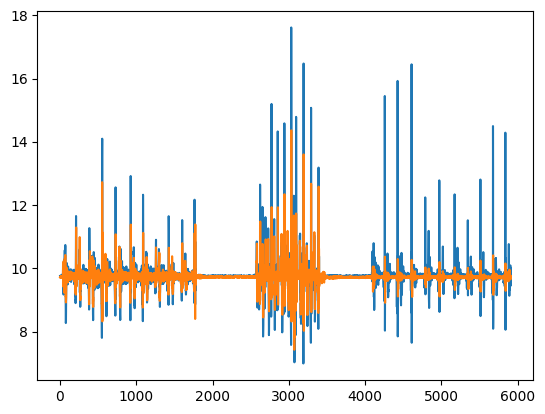

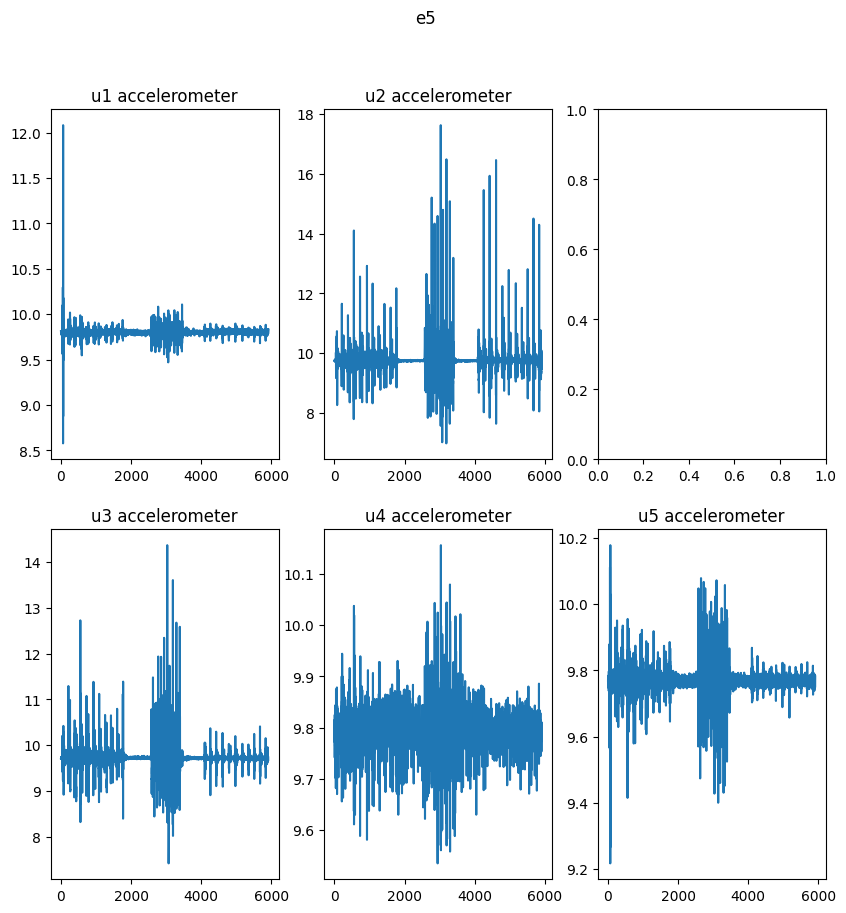

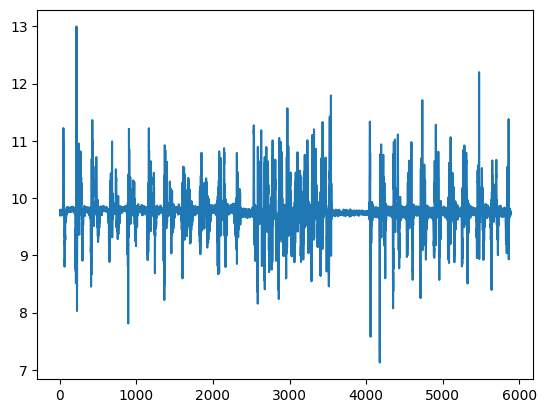

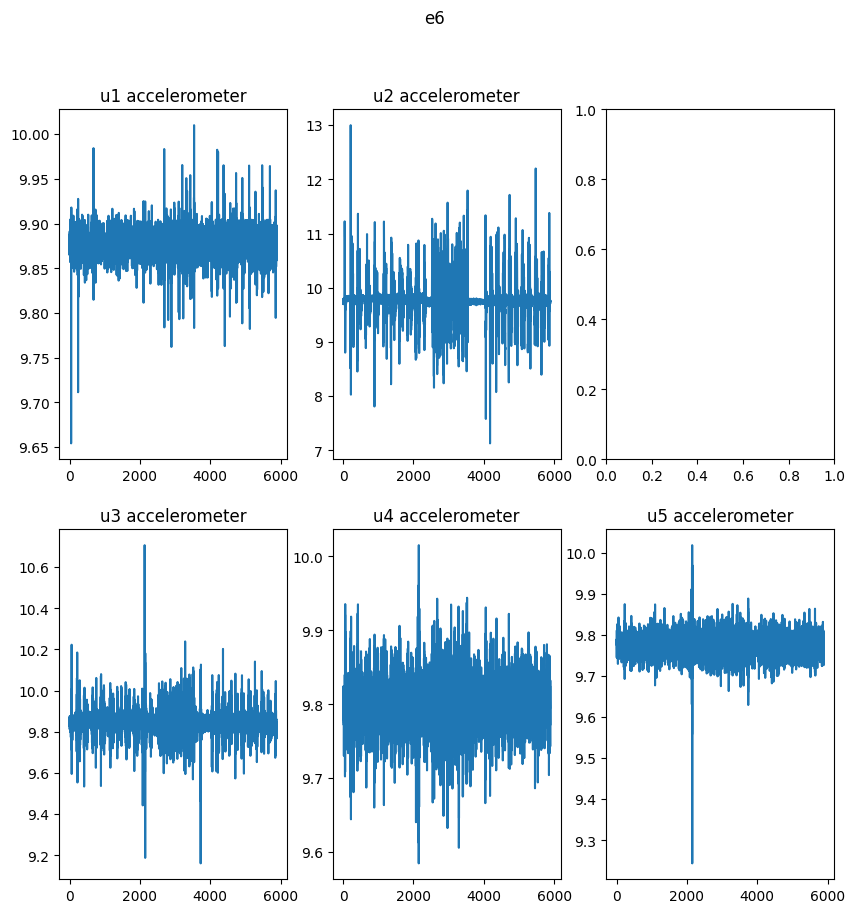

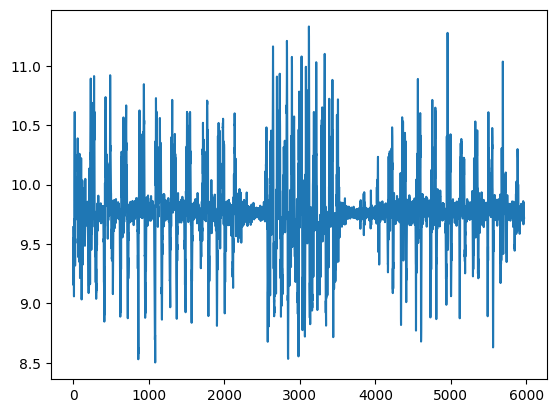

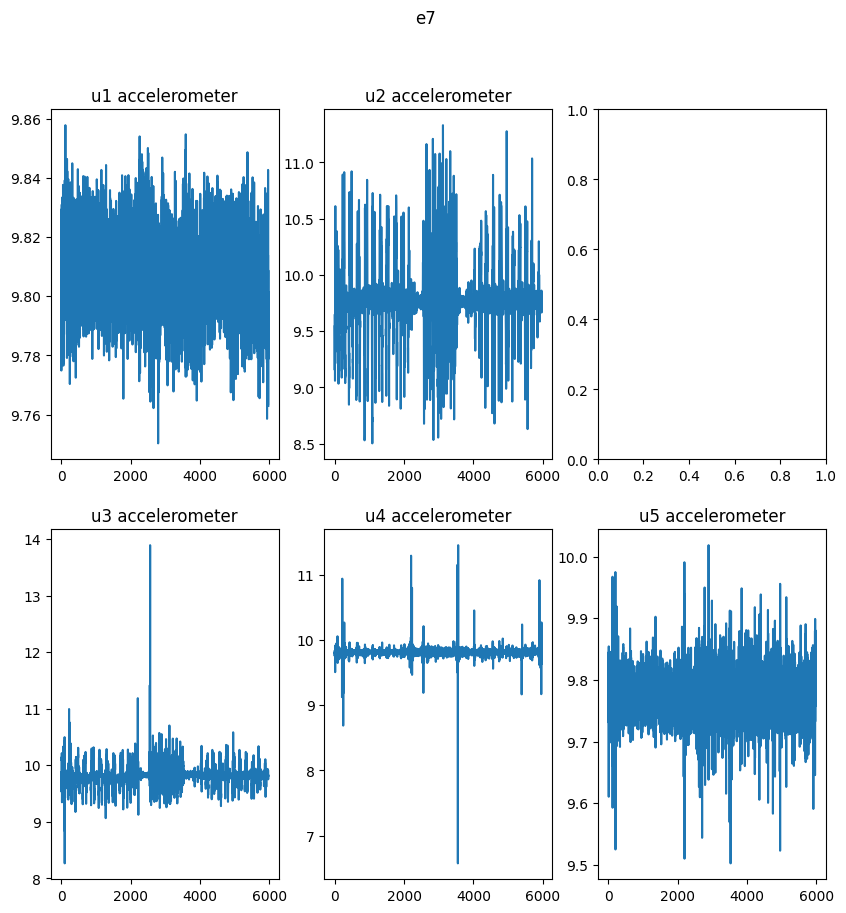

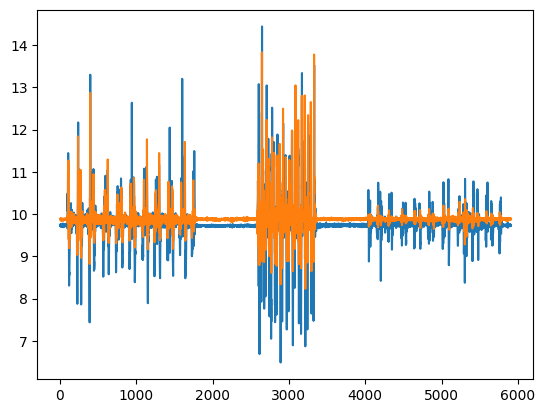

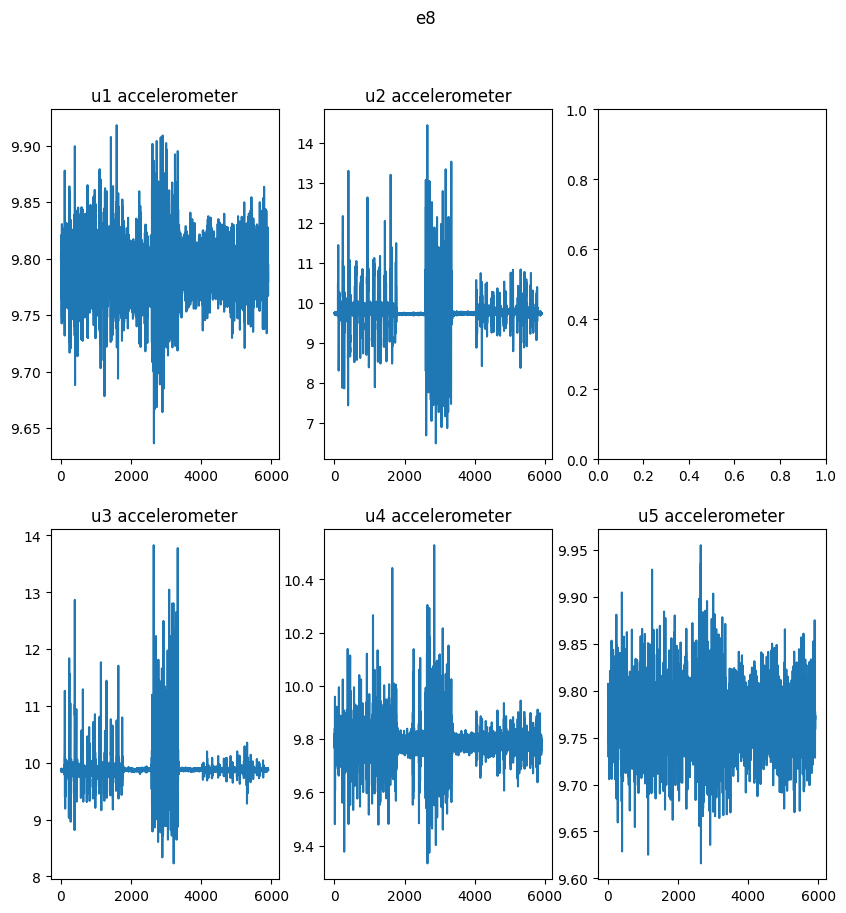

In [23]:

subject=merged_df[merged_df['subject']=='s1']

exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for exercise in exercises:
    subject_ex = subject[subject['exercise'] == exercise].copy()
    
    subject_ex["acc_mag_u1"] = np.sqrt(      
        subject_ex["acc_x_u1"]**2 +
        subject_ex["acc_y_u1"]**2 +
        subject_ex["acc_z_u1"]**2
    )

    subject_ex["acc_mag_u2"] = np.sqrt(      
        subject_ex["acc_x_u2"]**2 +
        subject_ex["acc_y_u2"]**2 +
        subject_ex["acc_z_u2"]**2
    )

    subject_ex["acc_mag_u3"] = np.sqrt(      
        subject_ex["acc_x_u3"]**2 +
        subject_ex["acc_y_u3"]**2 +
        subject_ex["acc_z_u3"]**2
    )

    subject_ex["acc_mag_u4"] = np.sqrt(      
        subject_ex["acc_x_u4"]**2 +
        subject_ex["acc_y_u4"]**2 +
        subject_ex["acc_z_u4"]**2
    )

    subject_ex["acc_mag_u5"] = np.sqrt(      
        subject_ex["acc_x_u5"]**2 +
        subject_ex["acc_y_u5"]**2 +
        subject_ex["acc_z_u5"]**2
    )

    threshold = 0.2   # example threshold

    for u in range(1,6):

        std = subject_ex[f"acc_mag_u{u}"].std()

        if std > threshold:
            plt.plot(subject_ex["time index"], subject_ex[f"acc_mag_u{u}"],
                    label=f"u{u} (std={std:.2f})")



    fig, axes= plt.subplots(ncols=3, nrows=2, figsize=(10,10))
    fig.suptitle(exercise)
    axes[0,0].plot(subject_ex["time index"], subject_ex["acc_mag_u1"])
    axes[0,0].set_title('u1 accelerometer')

    axes[0,1].plot(subject_ex["time index"], subject_ex["acc_mag_u2"])
    axes[0,1].set_title('u2 accelerometer')

    axes[1,0].plot(subject_ex["time index"], subject_ex["acc_mag_u3"])
    axes[1,0].set_title('u3 accelerometer')


    axes[1,1].plot(subject_ex["time index"],subject_ex["acc_mag_u4"])
    axes[1,1].set_title('u4 accelerometer')


    axes[1,2].plot(subject_ex["time index"], subject_ex["acc_mag_u5"])
    axes[1,2].set_title('u5 accelerometer')

    plt.show()